In [188]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter

In [189]:
from scipy.optimize import curve_fit
def power_law(x,A,B):
    return A*x**B
def exp_law(x,A,B,C):
    return A*np.exp(-B*x)+C
def fit(dat,X):
    params_power_law , cov_power_law = curve_fit(power_law, X, dat)
    #a_power_law, b_power_law = params_power_law
    params_exp_law, cov_exp_law = curve_fit(exp_law,X,dat,maxfev=1000)
    # plt.scatter(X,dat)
    # plt.loglog(X,power_law(X,*params_power_law),label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    # plt.loglog(X,exp_law(X,*params_exp_law),label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    # plt.legend()
    # plt.xlim(X[0],X[-1])
    #plt.ylim(0,1)
    #plt.show()
    print(np.sqrt(np.diag(cov_power_law)))
    print(np.sqrt(np.diag(cov_exp_law)))
    return params_power_law, params_exp_law



In [190]:
L =50
k=kb.k_vals(L)

U_0 = kb.U(k,2)



In [191]:
import numpy as np
from scipy.integrate import solve_ivp

def g(t, tau):
    g0= 2
    gf = 0
    return max(g0 + (gf - g0) * t / tau,0)


def rhs(t, v, k,tau): 
  #  print(g(t,tau))
    return [
        2 * ((g(t,tau) - np.cos(k)) * v[0] + np.sin(k) * v[1]) / 1j,
        2 * (-(g(t,tau) - np.cos(k)) * v[1] + np.sin(k) * v[0]) / 1j
    ]

from joblib import Parallel, delayed

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]



In [210]:
L =100
k=kb.k_vals(L)
v_0 = kb.U(k,2)
t_span = (0, 900)
t_eval = np.linspace(*t_span, 100)
Uf = kb.U(k,0)
taus = np.logspace(-1,2.5,50)
x= np.empty((10,len(taus)))

In [211]:

T = 0
for tau in taus:
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))
    final_time_evolve = np.array(results).T
    for j in range(8):
        x[j, T] = kb.P_n(j+2,Uf,k) - kb.P_n(j + 2, final_time_evolve, k)
    T += 1

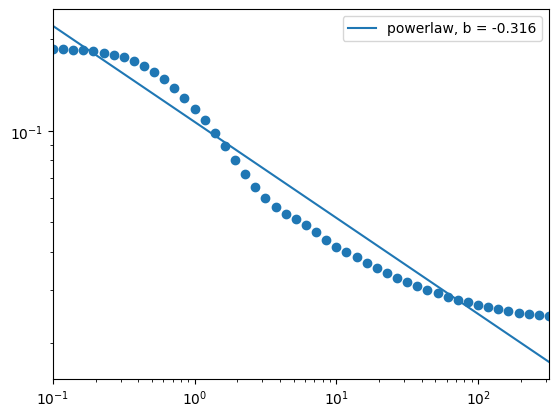

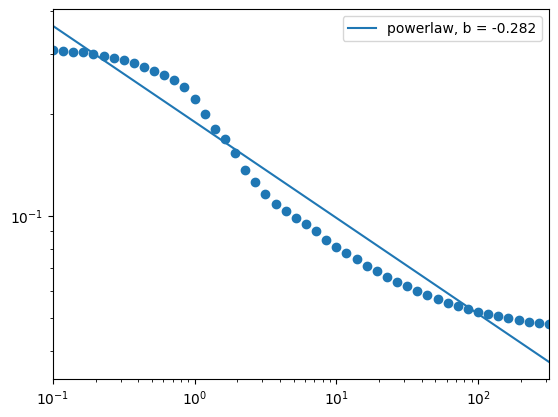

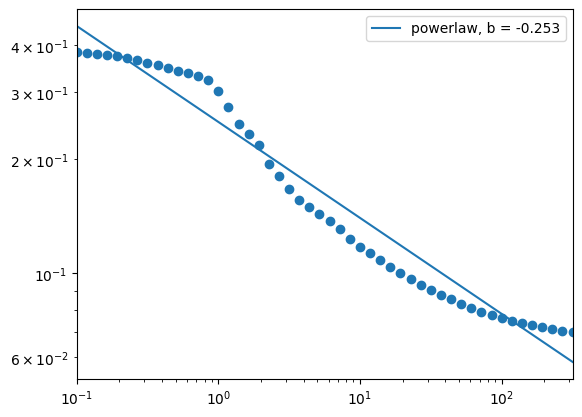

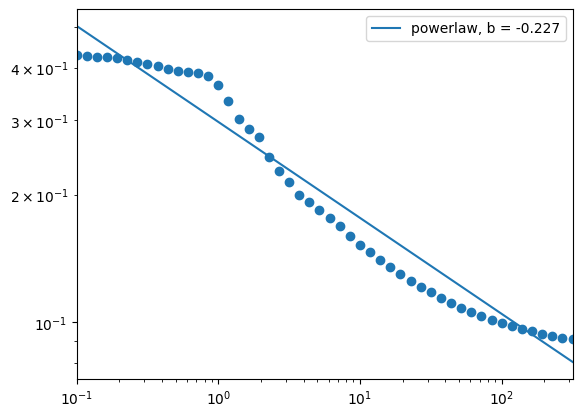

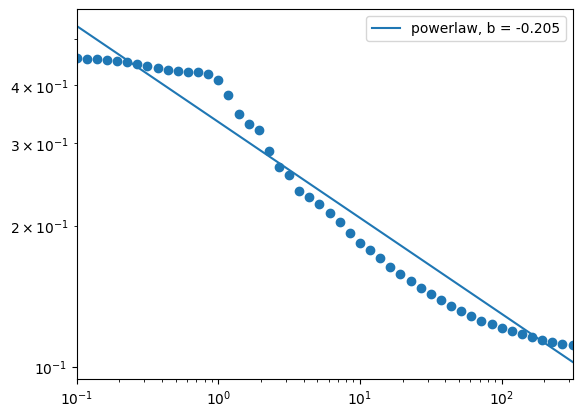

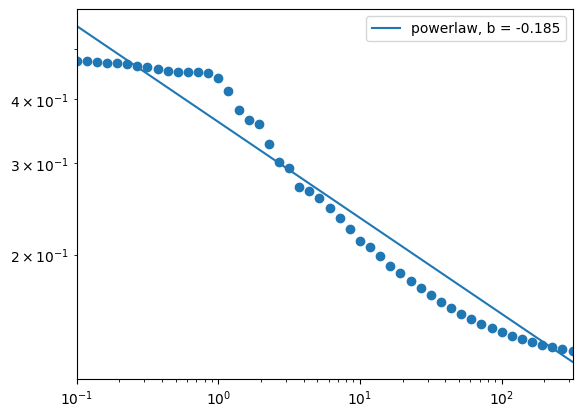

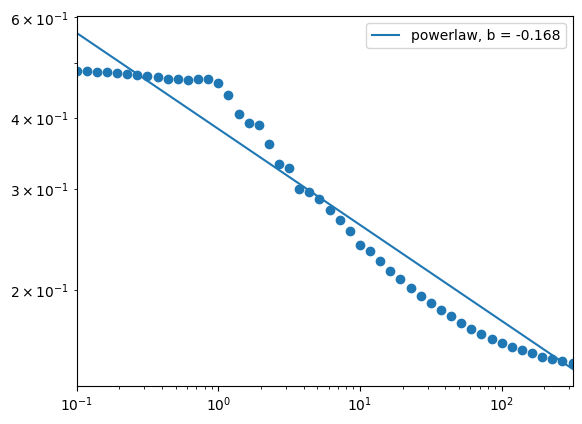

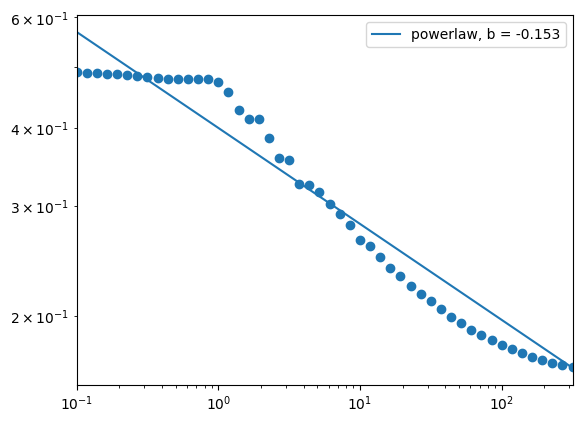

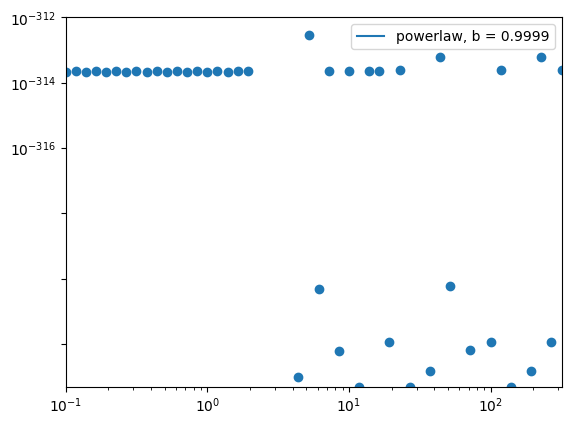

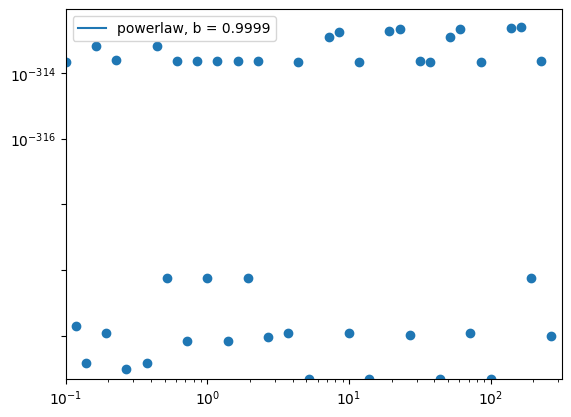

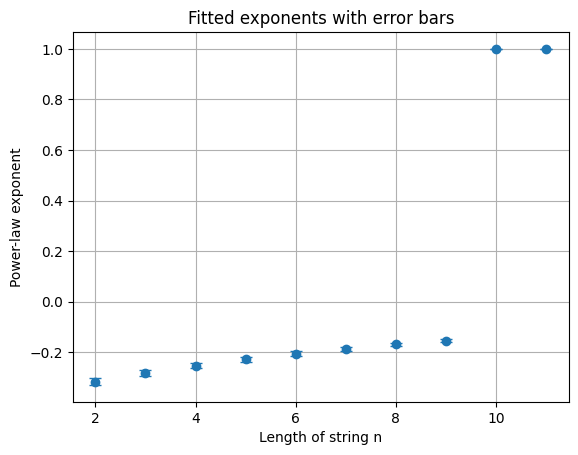

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law(x, A, B):
    return A * x**B

def exp_law(x, A, B, C):
    return A * np.exp(-B * x) + C

def fit(dat, X):
    params_power_law, cov_power_law = curve_fit(power_law, X, dat)
    params_exp_law, cov_exp_law = curve_fit(exp_law, X, dat, maxfev=1000)

    plt.scatter(X, dat)
    plt.loglog(X, power_law(X, *params_power_law), label=f"powerlaw, b = {str(params_power_law[1])[:6]}")
    #plt.loglog(X, exp_law(X, *params_exp_law), label=f"exp law, b = {str(params_exp_law[1])[:5]}")
    plt.legend()
    plt.xlim(X[0], X[-1])
    plt.show()

    return params_power_law, cov_power_law

exponents=[]
errors = []

for i in range(10):
    params_power, cov_power = fit(x.T[:, i], taus)
    exponents.append(params_power[1])
    err = np.sqrt(cov_power[1]) if cov_power.ndim == 1 else np.sqrt(cov_power[1,1])
    errors.append(err)

exponents = np.array(exponents)
errors = np.array(errors)

plt.errorbar(np.arange(2,12), exponents, yerr=errors, fmt='o', capsize=4)
plt.xlabel("Length of string n")
plt.ylabel("Power-law exponent")
plt.title("Fitted exponents with error bars")
plt.grid(True)
plt.show()


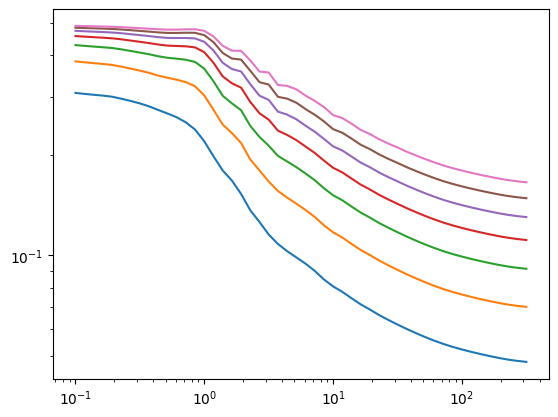

In [213]:

exponents = []
errors = []

for i in range(1,8):
    plt.plot(taus,x.T[:, i])
plt.yscale("log")
plt.xscale("log")

#plt.plot(taus,taus**(-1/2))

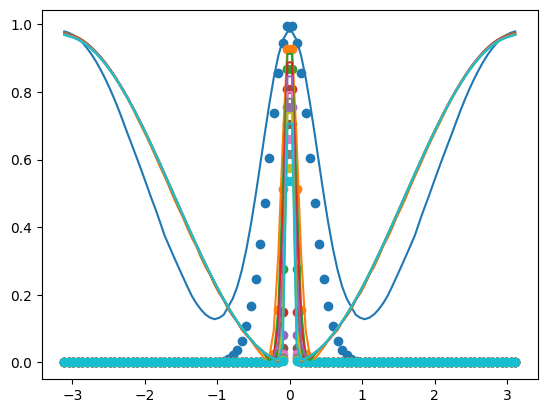

In [186]:
L =100
k=kb.k_vals(L)

from joblib import Parallel, delayed

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]
taus = np.linspace(1,100,10)
v_0 = kb.U(k,2)

T = 0
for tau in taus:
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))
    final_time_evolve = np.array(results).T
    T += 1
    plot(k,np.abs(final_time_evolve[0,:])**2)
    plt.scatter(k,np.exp(-2*np.pi*k**2*tau))

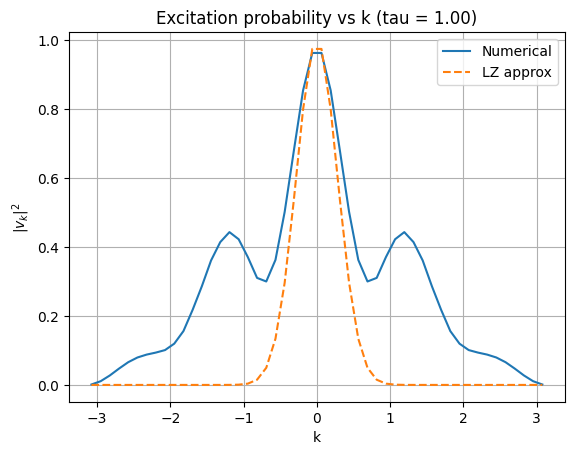

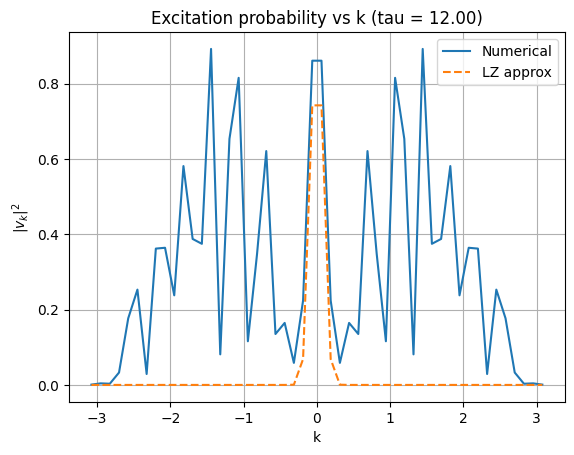

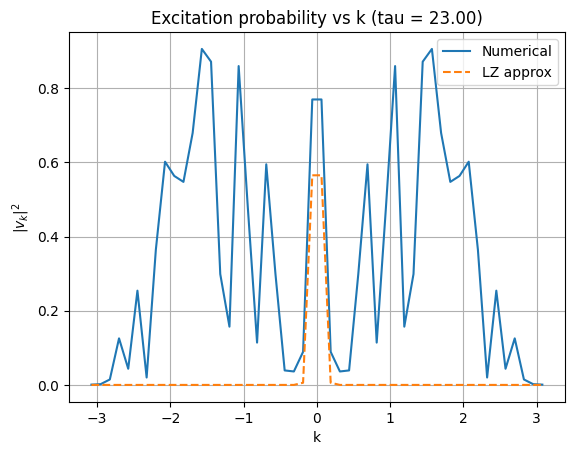

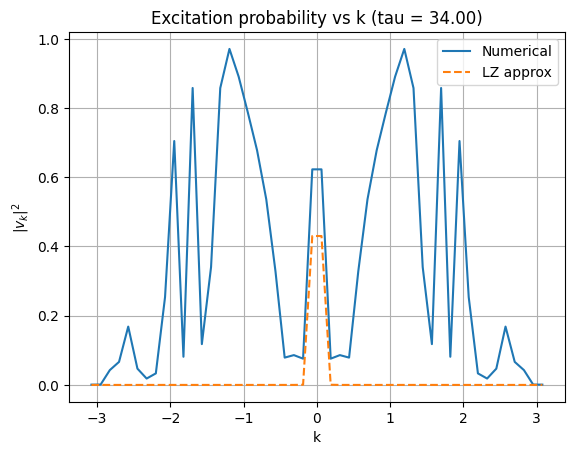

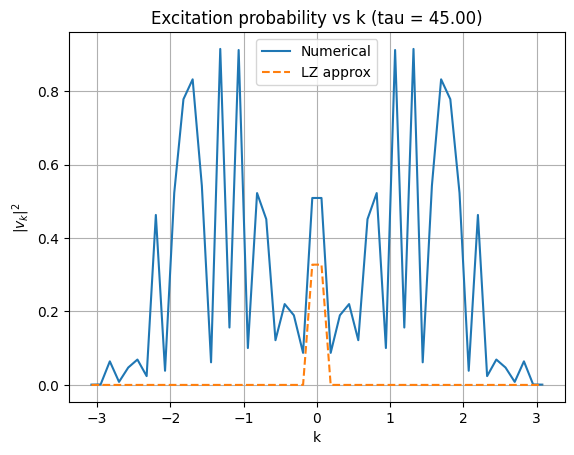

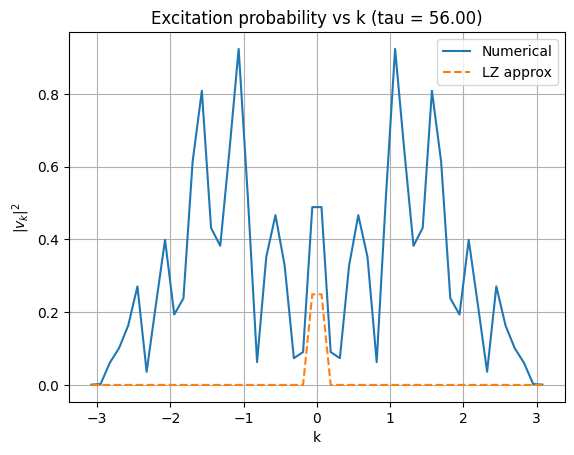

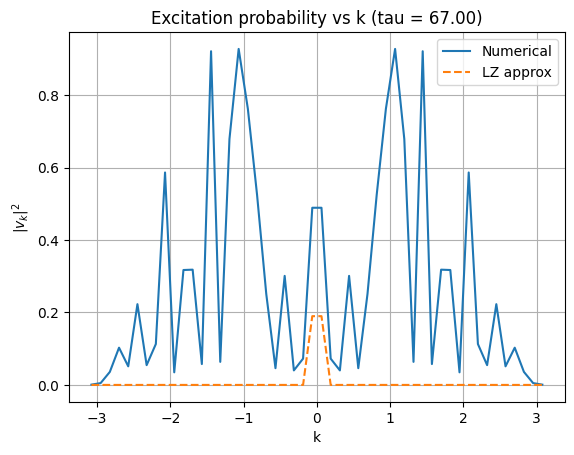

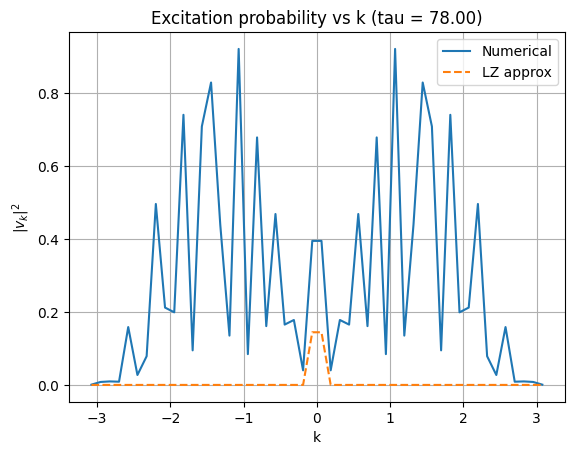

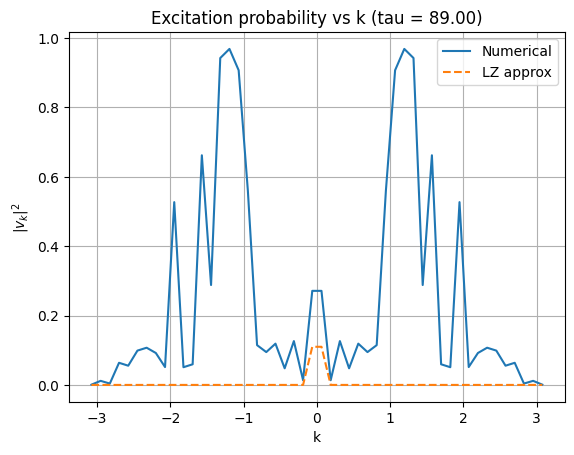

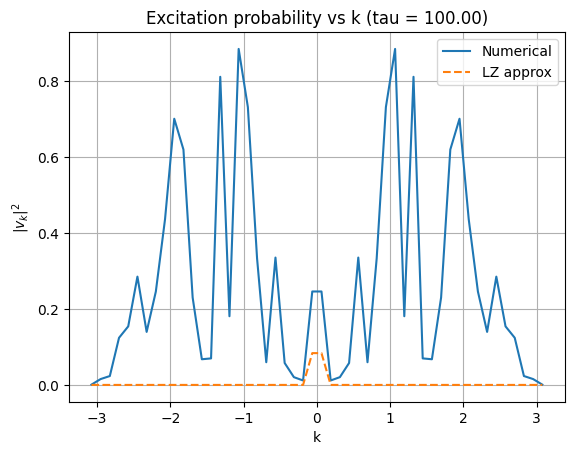

In [187]:
L = 50
k = kb.k_vals(L)
v_0 = kb.U(k, 0)
t_span = (0, 300)
t_eval = np.linspace(*t_span, 1000)
taus = np.linspace(1, 100, 10)

def evolve_mode(i, v_0, k, t_span, t_eval, tau):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau), t_eval=t_eval)
    return res.y[0][-1], res.y[1][-1]

for tau in taus:
    results = Parallel(n_jobs=-1)(delayed(evolve_mode)(i, v_0, k, t_span, t_eval, tau) for i in range(len(k)))
    final_time_evolve = np.array(results).T
    plt.figure()
    plt.plot(k, np.abs(final_time_evolve[1, :])**2, label="Numerical")
    plt.plot(k, np.exp(-2*np.pi * k**2 * tau), '--', label="LZ approx")
    plt.title(f"Excitation probability vs k (tau = {tau:.2f})")
    plt.xlabel("k")
    plt.ylabel(r"$|v_k|^2$")
    plt.legend()
    plt.grid(True)
    plt.show()
